# 02 — The Lazuli targets

All simulations go through a *target* object. `slicersim` provides ready-to-use targets for the
main Lazuli science cases, plus `LazuliTarget` to simulate **any** spectrum. They all share the
same interface: `setup_to_snr()`, `get_exposure_time()`, `get_spectrum()`,
`change_properties()`, `get_cube()`...

| class | source | main parameters |
|---|---|---|
| `LazuliSupernova` | SN Ia, SALT2 model | `redshift`, `phase`, `x1`, `c`, `MBmax` |
| `LazuliKilonova` | kilonova, POSSIS models (Bulla 2019, 2023) | `redshift`, `phase` (days since merger), `theta` (viewing angle), `magabs` or `magobs` |
| `LazuliCalSpec` | HST CalSpec standard star | `name`, optional `mag`, `band` |
| `LazuliBlackBody` | blackbody | `temperature` [K], `mag`, `band` |
| `LazuliPowerLaw` | $F_\lambda \propto \lambda^{\alpha}$ | `alpha`, `mag`, `band` |
| `LazuliTarget` | **any spectrum** | `lbda`, `flux`, optional `mag`, `band` |

Each scene contains the point source on top of the zodiacal light background.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. The pre-built scientific targets

In [2]:
targets = {
    "SN Ia (z=1)":             slicersim.LazuliSupernova(redshift=1.0, x1=0, c=0, phase=0),
    "kilonova (z=0.05)":       slicersim.LazuliKilonova(redshift=0.05, phase=1.4, theta=30),
    "CalSpec GD71 (r=22)":     slicersim.LazuliCalSpec("gd71", mag=22, band="sdssr"),
    "blackbody 5000 K (r=22)": slicersim.LazuliBlackBody(temperature=5000, mag=22, band="sdssr"),
    "power law α=-2 (r=22)":   slicersim.LazuliPowerLaw(alpha=-2, mag=22, band="sdssr"),
}

The parameters describing a target are listed by `pointsource_properties`, and read with
`get_properties()`:

In [3]:
for name, target in targets.items():
    print(f"{name:25s}", [p.replace("pointsource.", "") for p in target.pointsource_properties])

SN Ia (z=1)               ['phase', 'abmag', 'redshift', 'MBmax', 'source', 'cosmo', 'x1', 'c', 'alpha', 'beta', 'position']
kilonova (z=0.05)         ['phase', 'redshift', 'theta', 'magobs', 'magabs', 'band', 'magsys', 'source', 'cosmo', 'position']
CalSpec GD71 (r=22)       ['mag', 'band', 'position']
blackbody 5000 K (r=22)   ['temperature', 'mag', 'band', 'magsys', 'position']
power law α=-2 (r=22)     ['alpha', 'mag', 'lambda_ref', 'band', 'magsys', 'position']


In [4]:
targets["SN Ia (z=1)"].get_properties(["redshift", "phase", "x1", "c"])

{'redshift': 1.0, 'phase': 0, 'x1': 0, 'c': 0}

Let us observe each of them with the **same** readout configuration — a single ramp of
~24 min (see notebook 03) — and look at their spectra.

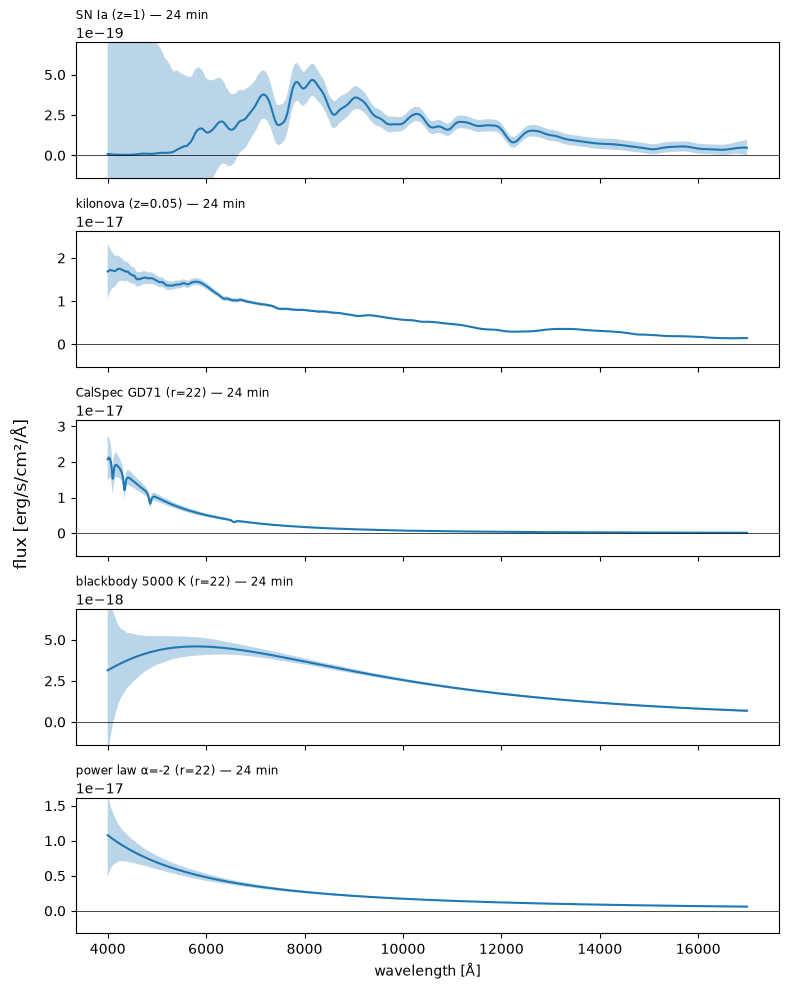

In [5]:
fig, axes = plt.subplots(len(targets), 1, figsize=(8, 10), sharex=True)
for ax, (name, target) in zip(axes, targets.items()):
    target.change_detector(nmd=(64, 8, 0), nramps=1)
    lbda, flux, variance = target.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda, flux, lw=1.5)
    ax.fill_between(lbda, flux - np.sqrt(variance), flux + np.sqrt(variance), alpha=0.3)
    ax.set_title(f"{name} — {target.get_exposure_time()/60:.0f} min", loc="left", fontsize="small")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylim(-0.3 * flux.max(), 1.5 * flux.max())

axes[-1].set_xlabel("wavelength [Å]")
fig.supylabel("flux [erg/s/cm²/Å]")
fig.tight_layout()

- `LazuliSupernova` also accepts any sncosmo SALT source through `model` (e.g. `model="salt3"`).
- `LazuliCalSpec` downloads the star from the CalSpec archive; the list of available names is in
  `target.source_names`. Without `mag`, the measured CalSpec flux is used.

***
## 2. `LazuliTarget`: simulate any observation

Give `LazuliTarget` a wavelength array (Å) and a flux (erg/s/cm²/Å). If `mag` is given, the
flux is rescaled to that magnitude in `band`.

As an example, let us build a toy star-forming galaxy at $z=1.4$: a continuum plus emission
lines ([OII], Hβ, [OIII], Hα+[NII]), which all fall in the Lazuli range at that redshift.

In [6]:
def emission_line_galaxy(lbda, redshift=1.4, ew=[60, 20, 30, 90, 150, 50], sigma=4.):
    """ Toy star-forming galaxy: power-law continuum + Gaussian emission lines.

    lbda in Å (observer frame); ew are the rest-frame equivalent widths [Å] of
    [OII], Hβ, [OIII]4959, [OIII]5007, Hα, [NII]6583; sigma the rest-frame line width [Å].
    """
    lines = [3727, 4861, 4959, 5007, 6563, 6583]  # rest-frame [Å]
    lbda_rest = lbda / (1 + redshift)
    continuum = (lbda_rest / 5000) ** -1.5
    spectrum = continuum.copy()
    for line, ew_ in zip(lines, ew):
        profile = np.exp(-0.5 * ((lbda_rest - line) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)
        spectrum += ew_ * continuum * profile
    return spectrum

In [7]:
lbda_in = np.arange(3_000, 20_000, 1.0)
flux_in = emission_line_galaxy(lbda_in, redshift=1.4)

galaxy = slicersim.LazuliTarget(lbda_in, flux_in, mag=24, band="sdssi")
galaxy.pointsource_properties

['pointsource.mag', 'pointsource.band', 'pointsource.position']

Everything from notebook 01 works the same. Let us reach SNR=5 per resolution element in the
continuum between 10 000 and 12 000 Å (observer frame):

In [8]:
config, snr = galaxy.setup_to_snr(5, lbda_range=[10_000, 12_000], frame="obs")
print(config, f"SNR={snr:.1f}", f"exposure time: {galaxy.get_exposure_time()/3600:.1f} h")

{'nmd': (31, 8, 0), 'nramps': 1} SNR=5.7 exposure time: 0.2 h


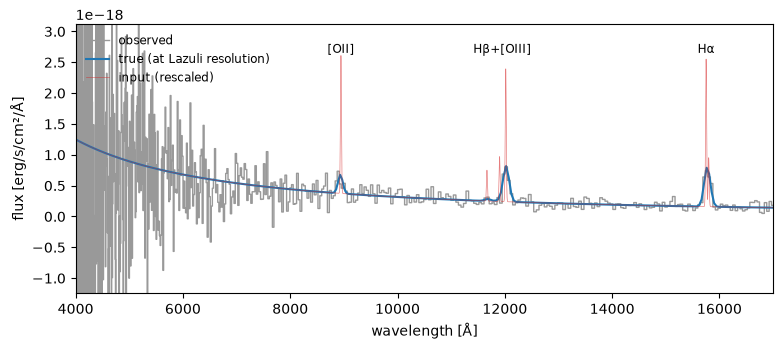

In [9]:
lbda, flux, variance = galaxy.get_spectrum(unit="flambda")
_, flux_true, _ = galaxy.get_spectrum(unit="flambda", incl_error=False)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, flux, color="0.6", lw=1, ds="steps-mid", label="observed")
ax.plot(lbda, flux_true, color="C0", label="true (at Lazuli resolution)")
ax.plot(lbda_in, flux_in * np.nanmedian(flux_true / np.interp(lbda, lbda_in, flux_in)),
        color="C3", lw=0.5, alpha=0.6, label="input (rescaled)")
ax.set_ylim(-1 * flux_true.max(), 2.5 * flux_true.max())
for name, line in {"[OII]": 3727, "Hβ+[OIII]": 4980, "Hα": 6563}.items():
    ax.text(line * 2.4, ax.get_ylim()[1] * 0.85, name, ha="center", fontsize="small")
ax.set(xlabel="wavelength [Å]", ylabel="flux [erg/s/cm²/Å]", xlim=(4000, 17000))
ax.legend(fontsize="small", frameon=False, loc="upper left")

The narrow input lines are broadened to the Lazuli spectral resolution (line spread function).

The input spectrum as seen by the simulation (at the Lazuli wavelength sampling, before
the instrument) is accessible from the underlying `Simulation` object:

In [10]:
lbda_sim, flux_input = galaxy.simulation.get_input_spectrum()  # erg/s/cm²/Å
flux_input[:5]

array([1.24953113e-18, 1.24732307e-18, 1.24511411e-18, 1.24290421e-18,
       1.24069334e-18])

***
## Recap

- Pre-built targets: `LazuliSupernova`, `LazuliKilonova`, `LazuliCalSpec`, `LazuliBlackBody`,
  `LazuliPowerLaw`; any spectrum: `LazuliTarget(lbda, flux, mag, band)`.
- `pointsource_properties` lists what describes the target; `get_properties()` reads them.
- They all share the same methods.

**Next:** [03 — Detector configuration and exposure time](03_detector_and_exposure_time.ipynb)